# A题问题1：逐行实际形状—严格截断 GJK—并查集判定与 BFS 路径

本 Notebook 是一个**独立完整的计算文件**：圆柱支持函数、Signed-Volumes GJK、严格截断形状、
附件读取、距离建图、并查集和 BFS 均在下方单元中直接定义，不导入工作区内任何 `.py` 代码。

唯一外部数据输入为题目提供的 `附件.xlsx`。计算口径为：

1. Excel 中每一行直接作为一个独立导体节点；
2. 不识别或拼接同源行，不恢复 5000 nm 父圆柱，不补全缺失轴段；
3. 不生成或平移任何附件未列出的周期副本；
4. 内部端点作为真实圆形端盖，边界端点作为边界平面切点；
5. AABB 和未截断辅助圆柱只用于安全粗筛，最终距离由严格截断支持函数 + GJK 给出；
6. 左右两个 X 面是不同电极：并查集判断是否导通；导通后再用 BFS 提取展示路径。

运行依赖：`numpy`、`pandas`、`scipy`、`openpyxl`、`matplotlib` 和 `IPython`。

In [2]:
from __future__ import annotations

from collections import deque
from dataclasses import dataclass
from functools import cached_property
from itertools import combinations
from pathlib import Path
from time import perf_counter
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from openpyxl import load_workbook
from scipy.optimize import linprog, minimize, nnls

np.set_printoptions(precision=10, suppress=True)
pd.set_option("display.max_colwidth", 180)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
try:
    get_ipython().run_line_magic("matplotlib", "inline")
    IN_NOTEBOOK = True
except NameError:
    IN_NOTEBOOK = False

RADIUS_NM = 30.0
CONDUCTION_DISTANCE_NM = 1.8
CONDUCTION_THRESHOLD = CONDUCTION_DISTANCE_NM
AUDIT_DISTANCE_NM = 2.5
BOUNDARY_TOL_NM = 1e-6

PROJECT_ROOT = Path.cwd()
INPUT_PATH = PROJECT_ROOT / "附件.xlsx"
if not INPUT_PATH.exists():
    raise FileNotFoundError(
        "找不到题目附件，请修改本单元中的 INPUT_PATH：\n" + str(INPUT_PATH.resolve())
    )

print("当前目录：", PROJECT_ROOT.resolve())
print("读取附件：", INPUT_PATH.resolve())
print("代码依赖：全部内嵌于本 Notebook，不读取本地 .py 文件")
print("计算口径：一行一个独立实际片段；不拼接、不补全、不生成周期副本")
print("导通阈值：", CONDUCTION_THRESHOLD, "nm")

当前目录： E:\华数杯\2026年第七届华数杯数学建模竞赛赛题\A题 微构体中填充导电介质的仿真优化
读取附件： E:\华数杯\2026年第七届华数杯数学建模竞赛赛题\A题 微构体中填充导电介质的仿真优化\附件.xlsx
代码依赖：全部内嵌于本 Notebook，不读取本地 .py 文件
计算口径：一行一个独立实际片段；不拼接、不补全、不生成周期副本
导通阈值： 1.8 nm


## 内嵌算法 A：有限圆柱与 Signed-Volumes GJK

本单元直接给出有限圆柱支持函数以及优化版 GJK 的距离子算法。

In [3]:
@dataclass(frozen=True)
class Cylinder:
    p0: np.ndarray
    p1: np.ndarray

    @cached_property
    def center(self) -> np.ndarray:
        return (self.p0 + self.p1) * 0.5

    @cached_property
    def axis(self) -> np.ndarray:
        d = self.p1 - self.p0
        return d / np.linalg.norm(d)

    @cached_property
    def half_length(self) -> float:
        return float(np.linalg.norm(self.p1 - self.p0) * 0.5)

    def support(self, direction: np.ndarray) -> np.ndarray:
        """Extreme point of a finite right circular cylinder."""
        u = self.axis
        axial_dot = float(np.dot(direction, u))
        cap = self.center + (self.half_length if axial_dot >= 0 else -self.half_length) * u
        radial_direction = direction - axial_dot * u
        radial_norm = float(np.linalg.norm(radial_direction))
        if radial_norm == 0.0:
            return cap
        return cap + RADIUS_NM * radial_direction / radial_norm

    def aabb(self) -> tuple[np.ndarray, np.ndarray]:
        u = self.axis
        extent = self.half_length * np.abs(u) + RADIUS_NM * np.sqrt(np.maximum(0.0, 1.0 - u * u))
        return self.center - extent, self.center + extent


def _affine_projection(points: np.ndarray) -> tuple[np.ndarray, np.ndarray] | None:
    """Project the origin on aff(points); return point and barycentrics."""
    n = len(points)
    gram = 2.0 * (points @ points.T)
    kkt = np.empty((n + 1, n + 1), dtype=float)
    kkt[:n, :n] = gram
    kkt[:n, n] = 1.0
    kkt[n, :n] = 1.0
    kkt[n, n] = 0.0
    rhs = np.zeros(n + 1)
    rhs[n] = 1.0
    try:
        solution = np.linalg.solve(kkt, rhs)
    except np.linalg.LinAlgError:
        return None
    weights = solution[:n]
    if not np.all(np.isfinite(weights)):
        return None
    return weights @ points, weights


def _closest_from_subsets(simplex: list[np.ndarray], require_new: bool) -> tuple[list[np.ndarray], np.ndarray, np.ndarray] | None:
    """Signed-volume/active-face search over admissible simplex faces."""
    candidates: list[tuple[float, int, tuple[int, ...], np.ndarray, np.ndarray]] = []
    m = len(simplex)
    indices = range(m)
    for size in range(m, 0, -1):
        for subset in combinations(indices, size):
            if require_new and 0 not in subset:
                continue
            pts = np.array([simplex[i] for i in subset], dtype=float)
            projection = _affine_projection(pts)
            if projection is None:
                continue
            point, weights = projection
            scale = max(1.0, float(np.max(np.linalg.norm(pts, axis=1))))
            weight_tol = 64.0 * np.finfo(float).eps * scale
            if np.min(weights) < -weight_tol:
                continue
            weights = np.maximum(weights, 0.0)
            weights /= np.sum(weights)
            point = weights @ pts
            candidates.append((float(np.dot(point, point)), -size, subset, weights, point))
    if not candidates:
        return None
    _, _, subset, weights, point = min(candidates, key=lambda x: (x[0], x[1]))
    return [simplex[i] for i in subset], weights, point


def signed_volumes_closest(simplex: list[np.ndarray]) -> tuple[list[np.ndarray], np.ndarray, np.ndarray]:
    """Algorithms 2--5: determinant/signed-volume distance sub-algorithm."""

    def choose(candidates: list[tuple[list[np.ndarray], np.ndarray, np.ndarray]]):
        return min(candidates, key=lambda item: float(np.dot(item[2], item[2])))

    def s1d(points: list[np.ndarray]):
        a, b = points
        direction = b - a
        denominator = float(np.dot(direction, direction))
        if denominator <= np.finfo(float).tiny:
            return [a], np.array([1.0]), a
        t = float(-np.dot(a, direction) / denominator)
        if t <= 0.0:
            return [a], np.array([1.0]), a
        if t >= 1.0:
            return [b], np.array([1.0]), b
        weights = np.array([1.0 - t, t])
        return points, weights, weights @ np.asarray(points)

    def s2d(points: list[np.ndarray]):
        pts = np.asarray(points)
        normal = np.cross(pts[1] - pts[0], pts[2] - pts[0])
        normal2 = float(np.dot(normal, normal))
        scale4 = max(1.0, float(np.max(np.linalg.norm(pts, axis=1))) ** 4)
        if normal2 <= 128.0 * np.finfo(float).eps * scale4:
            return choose([s1d([points[0], points[1]]), s1d([points[0], points[2]])])

        projected_origin = float(np.dot(pts[0], normal) / normal2) * normal
        discard_axis = int(np.argmax(np.abs(normal)))  # safest Cartesian projection
        keep = [axis for axis in range(3) if axis != discard_axis]
        matrix = np.vstack((pts[:, keep].T, np.ones(3)))
        rhs = np.array([projected_origin[keep[0]], projected_origin[keep[1]], 1.0])
        det_matrix = float(np.linalg.det(matrix))
        if not np.isfinite(det_matrix) or abs(det_matrix) <= np.finfo(float).tiny:
            return choose([s1d([points[0], points[1]]), s1d([points[0], points[2]])])
        # Cramer's rule: these determinant ratios are the signed areas in Alg. 4.
        weights = np.empty(3)
        for j in range(3):
            replaced = matrix.copy()
            replaced[:, j] = rhs
            weights[j] = np.linalg.det(replaced) / det_matrix
        if np.min(weights) >= -2e-12:
            weights = np.maximum(weights, 0.0)
            weights /= np.sum(weights)
            return points, weights, weights @ pts

        candidates = []
        for j in (1, 2):  # only faces containing the newly added point s1
            if weights[j] < 2e-12:
                candidates.append(s1d([points[i] for i in range(3) if i != j]))
        if candidates:
            return choose(candidates)
        fallback = _closest_from_subsets(points, require_new=False)
        return fallback if fallback is not None else ([points[0]], np.array([1.0]), points[0])

    def s3d(points: list[np.ndarray]):
        pts = np.asarray(points)
        matrix = np.vstack((pts.T, np.ones(4)))
        determinant = float(np.linalg.det(matrix))
        scale3 = max(1.0, float(np.max(np.linalg.norm(pts, axis=1))) ** 3)
        if not np.isfinite(determinant) or abs(determinant) <= 128.0 * np.finfo(float).eps * scale3:
            return choose([s2d([points[i] for i in range(4) if i != j]) for j in (1, 2, 3)])
        # Expansion along row 4 gives the signed tetrahedral volumes C_4j.
        cofactors = np.empty(4)
        for j in range(4):
            minor = np.delete(np.delete(matrix, 3, axis=0), j, axis=1)
            cofactors[j] = ((-1.0) ** (3 + j)) * np.linalg.det(minor)
        weights = cofactors / determinant
        if np.min(weights) >= -2e-12:
            weights = np.maximum(weights, 0.0)
            weights /= np.sum(weights)
            return points, weights, weights @ pts

        candidates = []
        for j in (1, 2, 3):  # discard only an old vertex, as in Algorithm 3
            if weights[j] < 2e-12:
                candidates.append(s2d([points[i] for i in range(4) if i != j]))
        if candidates:
            return choose(candidates)
        fallback = _closest_from_subsets(points, require_new=False)
        return fallback if fallback is not None else ([points[0]], np.array([1.0]), points[0])

    if len(simplex) == 1:
        return [simplex[0]], np.array([1.0]), simplex[0]
    if len(simplex) == 2:
        return s1d(simplex)
    if len(simplex) == 3:
        return s2d(simplex)
    return s3d(simplex)


def gjk_distance(a: Cylinder, b: Cylinder, max_iterations: int = 1024) -> tuple[float, int, bool]:
    """Distance between convex cylinders (Algorithm 1 + signed volumes)."""
    v = a.center - b.center
    if float(np.dot(v, v)) == 0.0:
        v = np.array([1.0, 0.0, 0.0])

    support_set: list[np.ndarray] = []
    seen: list[np.ndarray] = []
    eps_contact = 1e-14
    # Eq. (10), with epsilon_rel = 1e-6.  At a 1.8 nm query distance
    # this makes the absolute stopping error far below 1e-8 nm.
    eps_rel_sq = 1e-12

    for iteration in range(1, max_iterations + 1):
        w = a.support(-v) - b.support(v)
        v2 = float(np.dot(v, v))
        duplicate = any(np.array_equal(w, old) or np.linalg.norm(w - old) <= 1e-11 for old in seen)
        gap = v2 - float(np.dot(v, w))
        if support_set and (duplicate or gap <= eps_rel_sq * max(v2, 1.0)):
            return float(np.sqrt(max(v2, 0.0))), iteration, True

        simplex = [w, *support_set]
        support_set, _, v = signed_volumes_closest(simplex)
        seen.append(w)

        max_vertex2 = max(float(np.dot(y, y)) for y in support_set)
        v2 = float(np.dot(v, v))
        if len(support_set) == 4 or v2 <= eps_contact * max(1.0, max_vertex2):
            return 0.0, iteration, True

    return float(np.linalg.norm(v)), max_iterations, False

## 内嵌算法 B：严格截断圆柱支持函数

圆柱与轴对齐边界盒精确求交；圆周不离散为多边形。

In [4]:
def _null_space(matrix: np.ndarray, tol: float = 1e-12) -> np.ndarray:
    _, singular_values, vh = np.linalg.svd(matrix, full_matrices=True)
    rank = int(np.sum(singular_values > tol * max(1.0, singular_values[0] if len(singular_values) else 1.0)))
    return vh[rank:].T


@dataclass(frozen=True)
class ExactClippedCylinder:
    """Intersection of one finite circular cylinder and one axis-aligned box."""

    cylinder_center: np.ndarray
    axis: np.ndarray
    half_length: float
    radius: float
    box_low: np.ndarray
    box_high: np.ndarray
    lattice_index: tuple[int, int, int]

    @cached_property
    def _basis(self) -> tuple[np.ndarray, np.ndarray]:
        seed = np.array([1.0, 0.0, 0.0]) if abs(self.axis[0]) < 0.8 else np.array([0.0, 1.0, 0.0])
        e1 = np.cross(self.axis, seed)
        e1 /= np.linalg.norm(e1)
        return e1, np.cross(self.axis, e1)

    @cached_property
    def _map(self) -> np.ndarray:
        e1, e2 = self._basis
        return np.column_stack((self.half_length * self.axis, self.radius * e1, self.radius * e2))

    @cached_property
    def _linear_constraints(self) -> tuple[np.ndarray, np.ndarray]:
        # Dimensionless local variables z=(t/h,q1/r,q2/r), with
        # |z0|<=1 and z1^2+z2^2<=1.
        rows = [np.array([1.0, 0.0, 0.0]), np.array([-1.0, 0.0, 0.0])]
        rhs = [1.0, 1.0]
        for dim in range(3):
            rows.append(self._map[dim].copy())
            rhs.append(float(self.box_high[dim] - self.cylinder_center[dim]))
            rows.append(-self._map[dim].copy())
            rhs.append(float(self.cylinder_center[dim] - self.box_low[dim]))
        a = np.asarray(rows, dtype=float)
        b = np.asarray(rhs, dtype=float)
        norms = np.linalg.norm(a, axis=1)
        a /= norms[:, None]
        b /= norms
        return a, b

    def _feasible(self, z: np.ndarray, tol: float = 2e-9) -> bool:
        a, b = self._linear_constraints
        return bool(np.all(a @ z <= b + tol) and z[1] * z[1] + z[2] * z[2] <= 1.0 + tol)

    def _world(self, z: np.ndarray) -> np.ndarray:
        return self.cylinder_center + self._map @ z

    @cached_property
    def feasible_point_local(self) -> np.ndarray | None:
        """A feasible point, or None when the cylinder and box do not intersect."""
        a, b = self._linear_constraints
        lp = linprog(np.zeros(3), A_ub=a, b_ub=b, bounds=[(None, None)] * 3, method="highs")
        if not lp.success:
            return None
        start = lp.x
        result = minimize(
            lambda z: z[1] * z[1] + z[2] * z[2],
            start,
            jac=lambda z: np.array([0.0, 2.0 * z[1], 2.0 * z[2]]),
            constraints={"type": "ineq", "fun": lambda z: b - a @ z, "jac": lambda z: -a},
            method="SLSQP",
            options={"ftol": 1e-13, "maxiter": 300},
        )
        z = result.x
        if np.all(a @ z <= b + 2e-8) and z[1] * z[1] + z[2] * z[2] <= 1.0 + 2e-8:
            return z
        return None

    @property
    def exists(self) -> bool:
        return self.feasible_point_local is not None

    def _candidate_points(self, objective: np.ndarray) -> list[np.ndarray]:
        a, b = self._linear_constraints
        dmat = np.diag([0.0, 1.0, 1.0])
        candidates: list[np.ndarray] = []

        def add(z: np.ndarray) -> None:
            if np.all(np.isfinite(z)) and self._feasible(z):
                candidates.append(z)

        # Ordinary finite-cylinder support; retained if it also lies in the box.
        qnorm = float(np.linalg.norm(objective[1:]))
        z = np.zeros(3)
        z[0] = 1.0 if objective[0] >= 0.0 else -1.0
        if qnorm > 1e-15:
            z[1:] = objective[1:] / qnorm
        add(z)

        # Smooth circular side plus one or two active linear clipping planes.
        for size in (1, 2):
            for subset in combinations(range(len(a)), size):
                cmat = a[list(subset)]
                values = b[list(subset)]
                if np.linalg.matrix_rank(cmat, tol=1e-11) != size:
                    continue
                gram = cmat @ cmat.T
                y0 = cmat.T @ np.linalg.solve(gram, values)
                null = _null_space(cmat)
                hessian = null.T @ dmat @ null
                eigvals = np.linalg.eigvalsh(hessian)
                if len(eigvals) == 0 or eigvals[0] <= 2e-11:
                    continue
                linear = null.T @ dmat @ y0
                h_inv_linear = np.linalg.solve(hessian, linear)
                center = -h_inv_linear
                radius2 = float(linear @ h_inv_linear - (y0 @ dmat @ y0 - 1.0))
                if radius2 < -2e-9:
                    continue
                radius2 = max(0.0, radius2)
                projected_objective = null.T @ objective
                h_inv_objective = np.linalg.solve(hessian, projected_objective)
                denominator = float(projected_objective @ h_inv_objective)
                if denominator > 1e-20:
                    local = center + np.sqrt(radius2 / denominator) * h_inv_objective
                    add(y0 + null @ local)
                else:
                    # Objective is constant on this ellipse; sample principal ends
                    # so that remaining inequality feasibility can select one.
                    eigenvalues, eigenvectors = np.linalg.eigh(hessian)
                    for k in range(len(eigenvalues)):
                        step = np.sqrt(radius2 / eigenvalues[k]) * eigenvectors[:, k]
                        add(y0 + null @ (center + step))
                        add(y0 + null @ (center - step))

        # Vertices formed by three active cap/box planes, with radial constraint inactive or active.
        for subset in combinations(range(len(a)), 3):
            matrix = a[list(subset)]
            if abs(np.linalg.det(matrix)) <= 1e-11:
                continue
            add(np.linalg.solve(matrix, b[list(subset)]))
        return candidates

    def _kkt_certified(self, z: np.ndarray, objective: np.ndarray) -> bool:
        a, b = self._linear_constraints
        gaps = b - a @ z
        active = np.flatnonzero(gaps <= 2e-7)
        generators = [a[active].T] if len(active) else []
        radial = z[1] * z[1] + z[2] * z[2]
        if radial >= 1.0 - 2e-7:
            generators.append(np.array([[0.0], [2.0 * z[1]], [2.0 * z[2]]]))
        if not generators:
            return np.linalg.norm(objective) <= 1e-12
        matrix = np.column_stack(generators)
        coefficients, residual = nnls(matrix, objective)
        _ = coefficients
        return bool(residual <= 2e-7 * max(1.0, np.linalg.norm(objective)))

    def _slsqp_support(self, objective: np.ndarray, start: np.ndarray) -> np.ndarray:
        a, b = self._linear_constraints
        constraints = [
            {"type": "ineq", "fun": lambda z: b - a @ z, "jac": lambda z: -a},
            {
                "type": "ineq",
                "fun": lambda z: 1.0 - z[1] * z[1] - z[2] * z[2],
                "jac": lambda z: np.array([0.0, -2.0 * z[1], -2.0 * z[2]]),
            },
        ]
        result = minimize(
            lambda z: -float(objective @ z),
            start,
            jac=lambda z: -objective,
            constraints=constraints,
            method="SLSQP",
            options={"ftol": 2e-13, "maxiter": 500},
        )
        if not self._feasible(result.x, tol=2e-7):
            raise RuntimeError(f"Exact support optimization failed: {result.message}")
        return result.x

    def support(self, direction: np.ndarray) -> np.ndarray:
        norm = float(np.linalg.norm(direction))
        if norm == 0.0:
            return self.center
        objective = self._map.T @ (direction / norm)
        objective_norm = float(np.linalg.norm(objective))
        if objective_norm == 0.0:
            return self.center
        objective /= objective_norm

        candidates = self._candidate_points(objective)
        feasible = self.feasible_point_local
        if feasible is None:
            raise RuntimeError("Support requested for an empty clipped cylinder")
        best = max(candidates, key=lambda z: float(objective @ z)) if candidates else feasible
        if not self._kkt_certified(best, objective):
            best = self._slsqp_support(objective, best)
        return self._world(best)

    @cached_property
    def _axis_supports(self) -> tuple[np.ndarray, ...]:
        directions = (
            np.array([1.0, 0.0, 0.0]), np.array([-1.0, 0.0, 0.0]),
            np.array([0.0, 1.0, 0.0]), np.array([0.0, -1.0, 0.0]),
            np.array([0.0, 0.0, 1.0]), np.array([0.0, 0.0, -1.0]),
        )
        return tuple(self.support(direction) for direction in directions)

    @cached_property
    def center(self) -> np.ndarray:
        # Convex average of feasible support points is feasible and stable as a
        # starting direction for GJK.
        return np.mean(np.asarray(self._axis_supports), axis=0)

    def aabb(self) -> tuple[np.ndarray, np.ndarray]:
        points = self._axis_supports
        low = np.array([points[1][0], points[3][1], points[5][2]])
        high = np.array([points[0][0], points[2][1], points[4][2]])
        return low, high

## 内嵌算法 C：附件读取、逐行实际片段与距离图

每一附件行产生一个独立节点，并在本单元内完成边界切面构造、粗筛、严格距离和 BFS 函数定义。

In [5]:
@dataclass(frozen=True)
class RowSegment:
    row_id: int
    p0: np.ndarray
    p1: np.ndarray
    axis: np.ndarray
    length: float


def load_segments(input_path: Path) -> dict[str, tuple[np.ndarray, list[RowSegment]]]:
    """Read every worksheet; skip the two attachment header rows."""
    workbook = load_workbook(input_path, data_only=True, read_only=True)
    result: dict[str, tuple[np.ndarray, list[RowSegment]]] = {}
    for worksheet in workbook.worksheets:
        values = np.asarray(list(worksheet.values)[2:], dtype=float)
        half_box = np.max(np.abs(values.reshape(-1, 3)), axis=0)
        half_box[np.isclose(half_box, 5000.0, atol=1e-7)] = 5000.0
        half_box[np.isclose(half_box, 500.0, atol=1e-7)] = 500.0
        segments: list[RowSegment] = []
        for row_id, row in enumerate(values, start=1):
            direction = row[3:] - row[:3]
            length = float(np.linalg.norm(direction))
            if length <= 0.0:
                raise ValueError(f"{worksheet.title} 第{row_id}行轴段长度为0")
            segments.append(
                RowSegment(row_id, row[:3], row[3:], direction / length, length)
            )
        result[worksheet.title] = (half_box, segments)
    return result


@dataclass
class PieceNode:
    piece_id: int
    source_rows: list[int]
    start_boundary_faces: tuple[str, ...]
    end_boundary_faces: tuple[str, ...]
    geometry: ExactClippedCylinder


def boundary_faces(point: np.ndarray, half_box: np.ndarray) -> tuple[str, ...]:
    """Return every box face containing *point* within the attachment tolerance."""
    labels = ("X-", "Y-", "Z-", "X+", "Y+", "Z+")
    values = np.concatenate((-half_box, half_box))
    coordinates = np.concatenate((point, point))
    return tuple(
        label for label, coordinate, boundary in zip(labels, coordinates, values)
        if abs(float(coordinate - boundary)) <= BOUNDARY_TOL_NM
    )


def _box_projection_bounds(reference: np.ndarray, axis: np.ndarray, half_box: np.ndarray) -> tuple[float, float]:
    """Bounds of axis.dot(x-reference) for every x in the base-cell box."""
    low_terms = np.minimum((-half_box - reference) * axis, (half_box - reference) * axis)
    high_terms = np.maximum((-half_box - reference) * axis, (half_box - reference) * axis)
    return float(np.sum(low_terms)), float(np.sum(high_terms))


def build_row_piece(segment: RowSegment, half_box: np.ndarray) -> PieceNode:
    """Build the exact in-box solid represented by one attachment row.

    Boundary endpoints are not treated as perpendicular circular caps.  The
    auxiliary finite cylinder is extended beyond all possible in-box axial
    projections, then clipped by the box; hence its artificial outer cap cannot
    affect the resulting in-box geometry.
    """
    start_faces = boundary_faces(segment.p0, half_box)
    end_faces = boundary_faces(segment.p1, half_box)
    projection_low, projection_high = _box_projection_bounds(segment.p0, segment.axis, half_box)

    axial_low = 0.0 if not start_faces else min(0.0, projection_low) - RADIUS_NM
    axial_high = segment.length if not end_faces else max(segment.length, projection_high) + RADIUS_NM
    center = segment.p0 + 0.5 * (axial_low + axial_high) * segment.axis
    half_length = 0.5 * (axial_high - axial_low)
    piece = ExactClippedCylinder(
        center,
        segment.axis,
        half_length,
        RADIUS_NM,
        -half_box,
        half_box,
        (0, 0, 0),
    )
    if not piece.exists:
        raise RuntimeError(f"Attachment row {segment.row_id} has an empty clipped solid")
    return PieceNode(segment.row_id, [segment.row_id], start_faces, end_faces, piece)


def build_row_pieces(segments: list[RowSegment], half_box: np.ndarray) -> list[PieceNode]:
    """Create exactly one independent graph node per attachment row."""
    return [build_row_piece(segment, half_box) for segment in segments]


def aabb_separation(a: tuple[np.ndarray, np.ndarray], b: tuple[np.ndarray, np.ndarray]) -> float:
    delta = np.maximum(0.0, np.maximum(a[0] - b[1], b[0] - a[1]))
    return float(np.linalg.norm(delta))


def outer_cylinder(piece: ExactClippedCylinder) -> Cylinder:
    p0 = piece.cylinder_center - piece.half_length * piece.axis
    p1 = piece.cylinder_center + piece.half_length * piece.axis
    return Cylinder(p0, p1)


def exact_piece_distance(a: ExactClippedCylinder, b: ExactClippedCylinder) -> tuple[float, int, bool]:
    outer_a, outer_b = outer_cylinder(a), outer_cylinder(b)
    if aabb_separation(outer_a.aabb(), outer_b.aabb()) > AUDIT_DISTANCE_NM:
        return np.inf, 0, True
    lower_bound, _, _ = gjk_distance(outer_a, outer_b)
    if lower_bound > AUDIT_DISTANCE_NM:
        return np.inf, 0, True
    return gjk_distance(a, b)


def analyze(nodes: list[PieceNode], half_box: np.ndarray) -> dict:
    count = len(nodes)
    aabbs = [node.geometry.aabb() for node in nodes]
    adjacency = np.zeros((count, count), dtype=np.uint8)
    close_pairs = []
    audited = []
    exact_calls = 0
    nonconverged = 0

    for i, j in combinations(range(count), 2):
        if aabb_separation(aabbs[i], aabbs[j]) > AUDIT_DISTANCE_NM:
            continue
        distance, iterations, converged = exact_piece_distance(nodes[i].geometry, nodes[j].geometry)
        if not np.isfinite(distance):
            continue
        exact_calls += 1
        nonconverged += int(not converged)
        if distance <= AUDIT_DISTANCE_NM + 1e-9:
            audited.append((i + 1, j + 1, distance, iterations, converged))
        if distance <= CONDUCTION_DISTANCE_NM + 1e-9:
            adjacency[i, j] = adjacency[j, i] = 1
            close_pairs.append((i + 1, j + 1, distance, iterations))

    left_gap = np.array([max(0.0, aabb[0][0] + half_box[0]) for aabb in aabbs])
    right_gap = np.array([max(0.0, half_box[0] - aabb[1][0]) for aabb in aabbs])
    return {
        "adjacency": adjacency,
        "close_pairs": close_pairs,
        "audited": audited,
        "left_gap": left_gap,
        "right_gap": right_gap,
        "exact_calls": exact_calls,
        "nonconverged": nonconverged,
    }


def find_path(adjacency: np.ndarray, left: np.ndarray, right: np.ndarray) -> list[int] | None:
    queue = list(map(int, np.flatnonzero(left)))
    parents = {node: None for node in queue}
    for node in queue:
        if right[node]:
            end = node
            break
        for nxt in map(int, np.flatnonzero(adjacency[node])):
            if nxt not in parents:
                parents[nxt] = node
                queue.append(nxt)
    else:
        return None
    path = []
    while end is not None:
        path.append(end + 1)
        end = parents[end]
    return list(reversed(path))

## 1. 读取附件并审计轴段

附件中每一行的两个点只用于确定该独立片段的轴线方向和可见轴段。数据行编号从1开始，
与后续节点编号完全一致。

In [6]:
loaded = load_segments(INPUT_PATH)

input_rows = []
for sheet_name, (half_extents, segments) in loaded.items():
    lengths = np.asarray([segment.length for segment in segments])
    input_rows.append({
        "分组": sheet_name,
        "附件行数": len(segments),
        "独立节点数": len(segments),
        "最短轴段/nm": float(lengths.min()),
        "最长轴段/nm": float(lengths.max()),
        "轴长小于5000的行数": int(np.sum(lengths < 5000.0 - 1e-6)),
        "采用的半边界XYZ/nm": tuple(map(float, half_extents)),
    })

input_summary = pd.DataFrame(input_rows)
display(input_summary)
assert input_summary["附件行数"].equals(input_summary["独立节点数"])

,分组,附件行数,独立节点数,最短轴段/nm,最长轴段/nm,轴长小于5000的行数,采用的半边界XYZ/nm
0,组1,12,12,1019.117255,5000.0,10,"(5000.0, 500.0, 500.0)"
1,组2,49,49,577.473950,5000.0,38,"(5000.0, 500.0, 500.0)"
2,组3,535,535,525.697382,5000.0,380,"(5000.0, 5000.0, 5000.0)"


## 2. 逐行实际形状

对附件行轴线端点 \(A,B\)，内部端点作为真实圆形端盖；位于任一盒面的端点作为边界切点。
边界端点一侧只建立足够长的辅助圆柱，再与主单元盒求交，从而获得与边界面共面的真实切面。

\[
P_i=\{\text{第 }i\text{ 行的半径30 nm圆柱}\}\cap B.
\]

辅助圆柱的盒外部分不进入最终几何，不生成额外节点，也不平移到相对边界。

In [7]:
models: Dict[str, dict] = {}
endpoint_rows = []

for sheet_name, (half_extents, segments) in loaded.items():
    nodes = build_row_pieces(segments, half_extents)
    models[sheet_name] = {
        "half_extents": half_extents,
        "segments": segments,
        "nodes": nodes,
    }
    endpoint_rows.append({
        "分组": sheet_name,
        "附件行数": len(segments),
        "最终独立片段数": len(nodes),
        "补生成片段数": 0,
        "起点为边界切点": sum(bool(node.start_boundary_faces) for node in nodes),
        "终点为边界切点": sum(bool(node.end_boundary_faces) for node in nodes),
        "两端均为内部端盖": sum(
            not node.start_boundary_faces and not node.end_boundary_faces
            for node in nodes
        ),
    })

construction_summary = pd.DataFrame(endpoint_rows)
display(construction_summary)
assert construction_summary["附件行数"].equals(construction_summary["最终独立片段数"])
assert construction_summary["补生成片段数"].eq(0).all()

,分组,附件行数,最终独立片段数,补生成片段数,起点为边界切点,终点为边界切点,两端均为内部端盖
0,组1,12,12,0,7,6,2
1,组2,49,49,0,22,24,11
2,组3,535,535,0,206,204,155


## 3. 不补全与节点一一对应审计

本节验证三件事：每行恰好生成一个节点；节点编号等于附件数据行号；严格截断几何完全位于主单元内。
这里不存在父圆柱编号、同源合并、连续补全参数或周期单元索引。

In [8]:
geometry_audit_rows = []

for sheet_name, model in models.items():
    half_extents = model["half_extents"]
    nodes = model["nodes"]
    segments = model["segments"]
    all_inside = True
    endpoints_feasible = True

    for node, segment in zip(nodes, segments):
        lower, upper = node.geometry.aabb()
        all_inside &= bool(
            np.all(lower >= -half_extents - 2e-6)
            and np.all(upper <= half_extents + 2e-6)
        )
        for point in (segment.p0, segment.p1):
            local = np.linalg.solve(
                node.geometry._map,
                point - node.geometry.cylinder_center,
            )
            endpoints_feasible &= node.geometry._feasible(local, tol=2e-7)

    geometry_audit_rows.append({
        "分组": sheet_name,
        "节点编号唯一": len({node.piece_id for node in nodes}) == len(nodes),
        "节点编号=附件行号": all(
            node.piece_id == segment.row_id == node.source_rows[0]
            for node, segment in zip(nodes, segments)
        ),
        "全部片段位于主单元": all_inside,
        "附件轴线端点属于片段": endpoints_feasible,
        "补生成片段数": 0,
    })

geometry_audit = pd.DataFrame(geometry_audit_rows)
display(geometry_audit)
assert geometry_audit[["节点编号唯一", "节点编号=附件行号", "全部片段位于主单元", "附件轴线端点属于片段"]].all(axis=None)
assert geometry_audit["补生成片段数"].eq(0).all()

,分组,节点编号唯一,节点编号=附件行号,全部片段位于主单元,附件轴线端点属于片段,补生成片段数
0,组1,True,True,True,True,0
1,组2,True,True,True,True,0
2,组3,True,True,True,True,0


## 4. 真实截断片段的支持函数

片段采用 ExactClippedCylinder 表示，不把圆周离散成多边形。局部变量满足

\[
|z_0|\le 1,\qquad z_1^2+z_2^2\le1,\qquad Az\le b,
\]

每次支持查询直接求解约束下的线性目标。常规活动集使用线性方程、零空间椭圆极值和 KKT
条件；退化活动集使用三变量 SLSQP 回退。

In [9]:
support_audit_rows = []
coordinate_directions = np.vstack((np.eye(3), -np.eye(3)))

for sheet_name, model in models.items():
    maximum_violation = 0.0
    for node in model["nodes"]:
        geometry = node.geometry
        for direction in coordinate_directions:
            point = geometry.support(direction)
            local = np.linalg.solve(
                geometry._map,
                point - geometry.cylinder_center,
            )
            a, b = geometry._linear_constraints
            linear_violation = max(0.0, float(np.max(a @ local - b)))
            radial_violation = max(
                0.0,
                float(local[1] ** 2 + local[2] ** 2 - 1.0),
            )
            maximum_violation = max(maximum_violation, linear_violation, radial_violation)

    support_audit_rows.append({
        "分组": sheet_name,
        "检查片段数": len(model["nodes"]),
        "每片段坐标支持方向数": len(coordinate_directions),
        "最大无量纲约束残差": maximum_violation,
    })

support_audit = pd.DataFrame(support_audit_rows)
display(support_audit)
assert (support_audit["最大无量纲约束残差"] <= 2e-7).all()

,分组,检查片段数,每片段坐标支持方向数,最大无量纲约束残差
0,组1,12,6,2.042810e-14
1,组2,49,6,9.769963e-15
2,组3,535,6,5.351275e-14


## 5. AABB + GJK 距离算法

计算采用三级筛选：

1. 严格片段的 AABB 距离大于2.5 nm时安全排除；
2. 未裁剪辅助圆柱的 GJK 距离大于2.5 nm时安全排除；
3. 其余候选对使用真实截断支持函数和 Signed-Volumes GJK 计算最终距离。

前两级只给距离下界，最终 \(1.8\) nm 连边判断全部由第三级严格GJK给出。

In [10]:
class UnionFind:
    def __init__(self, size: int):
        self.parent = list(range(size))
        self.rank = [0] * size

    def find(self, node: int) -> int:
        while self.parent[node] != node:
            self.parent[node] = self.parent[self.parent[node]]
            node = self.parent[node]
        return node

    def union(self, first: int, second: int) -> None:
        root_first = self.find(first)
        root_second = self.find(second)
        if root_first == root_second:
            return
        if self.rank[root_first] < self.rank[root_second]:
            root_first, root_second = root_second, root_first
        self.parent[root_second] = root_first
        if self.rank[root_first] == self.rank[root_second]:
            self.rank[root_first] += 1


def conductive_by_union_find(
    adjacency: np.ndarray, left: np.ndarray, right: np.ndarray
) -> bool:
    piece_count = len(adjacency)
    left_electrode = piece_count
    right_electrode = piece_count + 1
    union_find = UnionFind(piece_count + 2)

    for first, second in np.argwhere(np.triu(adjacency, k=1)):
        union_find.union(int(first), int(second))
    for piece in np.flatnonzero(left):
        union_find.union(left_electrode, int(piece))
    for piece in np.flatnonzero(right):
        union_find.union(right_electrode, int(piece))

    return union_find.find(left_electrode) == union_find.find(right_electrode)


def solve_all_groups(models: Dict[str, dict]) -> Dict[str, dict]:
    solved: Dict[str, dict] = {}
    for sheet_name, model in models.items():
        print(f"正在计算 {sheet_name}：{len(model['nodes'])} 个独立片段……")
        started = perf_counter()
        analysis = analyze(model["nodes"], model["half_extents"])
        elapsed = perf_counter() - started

        left = analysis["left_gap"] <= CONDUCTION_THRESHOLD + 1e-9
        right = analysis["right_gap"] <= CONDUCTION_THRESHOLD + 1e-9
        conductive = conductive_by_union_find(analysis["adjacency"], left, right)
        path = (
            find_path(analysis["adjacency"], left, right)
            if conductive
            else None
        )
        assert conductive == (path is not None), "并查集判定与BFS路径检查不一致"
        solved[sheet_name] = {
            **model,
            **analysis,
            "left": left,
            "right": right,
            "path": path,
            "conductive": conductive,
            "connectivity_consistent": conductive == (path is not None),
            "elapsed_seconds": elapsed,
        }
        print(
            f"  AABB/下界筛选后严格GJK={analysis['exact_calls']}，"
            f"距离≤1.8 nm片段对={len(analysis['close_pairs'])}，"
            f"未收敛={analysis['nonconverged']}，耗时={elapsed:.2f}s"
        )
    return solved


results = solve_all_groups(models)

正在计算 组1：12 个独立片段……
  AABB/下界筛选后严格GJK=2，距离≤1.8 nm片段对=2，未收敛=0，耗时=0.11s
正在计算 组2：49 个独立片段……
  AABB/下界筛选后严格GJK=27，距离≤1.8 nm片段对=27，未收敛=0，耗时=10.22s
正在计算 组3：535 个独立片段……
  AABB/下界筛选后严格GJK=174，距离≤1.8 nm片段对=165，未收敛=0，耗时=35.33s


## 6. 独立片段导通图：并查集判定 + BFS 路径

对任意两个独立片段，只有严格GJK距离满足

\[
d(P_i,P_j)\le1.8\ {\rm nm}
\]

才建立无向边。片段到 \(x=-5000\) 和 \(x=5000\) 平面的距离分别决定是否连接左、右电极。
不存在任何隐藏身份边，也不计算周期镜像距离。所有片段边和电极边先加入并查集，
以左右电极的根节点是否相同作为最终导通判据；BFS 只在导通后提取一条可视化路径。

In [11]:
def node_label(result: dict, piece_id: int) -> str:
    return f"A{piece_id}(附件数据行{piece_id})"


def path_edge_table(sheet_name: str, result: dict) -> pd.DataFrame:
    if result["path"] is None:
        return pd.DataFrame()
    close_lookup = {
        tuple(sorted((i, j))): distance
        for i, j, distance, _ in result["close_pairs"]
    }
    rows = []
    path = result["path"]
    rows.append({
        "分组": sheet_name,
        "从": "L(左电极)",
        "到": node_label(result, path[0]),
        "连接类型": "左电极-片段",
        "精确距离/nm": float(result["left_gap"][path[0] - 1]),
    })
    for first, second in zip(path[:-1], path[1:]):
        rows.append({
            "分组": sheet_name,
            "从": node_label(result, first),
            "到": node_label(result, second),
            "连接类型": "片段-片段",
            "精确距离/nm": close_lookup[tuple(sorted((first, second)))],
        })
    rows.append({
        "分组": sheet_name,
        "从": node_label(result, path[-1]),
        "到": "R(右电极)",
        "连接类型": "片段-右电极",
        "精确距离/nm": float(result["right_gap"][path[-1] - 1]),
    })
    return pd.DataFrame(rows)

## 7. 计算三组微构体

汇总节点数、严格GJK调用、左右电极接触数和普通连通路径。

In [12]:
summary_rows = []
for sheet_name, result in results.items():
    path_text = (
        "无"
        if result["path"] is None
        else "L → " + " → ".join(f"A{i}" for i in result["path"]) + " → R"
    )
    summary_rows.append({
        "分组": sheet_name,
        "附件行数": len(result["segments"]),
        "独立片段数": len(result["nodes"]),
        "补生成片段数": 0,
        "距离≤1.8nm片段对": len(result["close_pairs"]),
        "接左电极片段数": int(np.sum(result["left"])),
        "接右电极片段数": int(np.sum(result["right"])),
        "严格GJK调用": result["exact_calls"],
        "GJK未收敛": result["nonconverged"],
        "并查集判定": "导通" if result["conductive"] else "不导通",
        "并查集/BFS一致": result["connectivity_consistent"],
        "一条BFS路径": path_text,
        "耗时/s": result["elapsed_seconds"],
    })

result_summary = pd.DataFrame(summary_rows)
display(result_summary)

for sheet_name, result in results.items():
    print(f"\n{sheet_name}：{'导通' if result['conductive'] else '不导通'}")
    if result["path"] is not None:
        display(path_edge_table(sheet_name, result))

,分组,附件行数,独立片段数,补生成片段数,距离≤1.8nm片段对,接左电极片段数,接右电极片段数,严格GJK调用,GJK未收敛,并查集判定,并查集/BFS一致,一条BFS路径,耗时/s
0,组1,12,12,0,2,3,4,2,0,不导通,True,无,0.108278
1,组2,49,49,0,27,11,11,27,0,导通,True,L → A2 → A12 → A24 → A39 → R,10.220321
2,组3,535,535,0,165,92,90,174,0,导通,True,L → A63 → A264 → A216 → A351 → R,35.332584



组1：不导通

组2：导通


,分组,从,到,连接类型,精确距离/nm
0,组2,L(左电极),A2(附件数据行2),左电极-片段,0.0
1,组2,A2(附件数据行2),A12(附件数据行12),片段-片段,0.0
2,组2,A12(附件数据行12),A24(附件数据行24),片段-片段,0.0
3,组2,A24(附件数据行24),A39(附件数据行39),片段-片段,0.0
4,组2,A39(附件数据行39),R(右电极),片段-右电极,0.0



组3：导通


,分组,从,到,连接类型,精确距离/nm
0,组3,L(左电极),A63(附件数据行63),左电极-片段,0.0
1,组3,A63(附件数据行63),A264(附件数据行264),片段-片段,0.0
2,组3,A264(附件数据行264),A216(附件数据行216),片段-片段,0.0
3,组3,A216(附件数据行216),A351(附件数据行351),片段-片段,0.0
4,组3,A351(附件数据行351),R(右电极),片段-右电极,0.0


## 8. 阈值与连通性审计

列出最接近1.8 nm的严格GJK结果，并独立检查组1的每个普通连通分量是否同时接触左右电极。
这取代了旧模型中不再存在的“父圆柱连续补全歧义”分析。

In [13]:
threshold_rows = []
for sheet_name, result in results.items():
    for i, j, distance, iterations, converged in result["audited"]:
        threshold_rows.append({
            "分组": sheet_name,
            "片段i": i,
            "片段j": j,
            "精确距离/nm": distance,
            "与1.8nm差值/nm": distance - CONDUCTION_THRESHOLD,
            "是否连接": distance <= CONDUCTION_THRESHOLD + 1e-9,
            "GJK迭代数": iterations,
            "是否收敛": converged,
        })

threshold_audit = pd.DataFrame(threshold_rows)
threshold_audit = threshold_audit.iloc[
    np.argsort(np.abs(threshold_audit["与1.8nm差值/nm"].to_numpy()))
].head(12).reset_index(drop=True)
display(threshold_audit)


def component_labels(adjacency: np.ndarray) -> np.ndarray:
    labels = np.full(len(adjacency), -1, dtype=int)
    component = 0
    for start in range(len(adjacency)):
        if labels[start] >= 0:
            continue
        queue = deque([start])
        labels[start] = component
        while queue:
            node = queue.popleft()
            for neighbor in np.flatnonzero(adjacency[node]):
                if labels[neighbor] < 0:
                    labels[neighbor] = component
                    queue.append(int(neighbor))
        component += 1
    return labels


group1_name = list(results)[0]
group1 = results[group1_name]
labels = component_labels(group1["adjacency"])
component_rows = []
for component in np.unique(labels):
    indices = np.flatnonzero(labels == component)
    component_rows.append({
        "连通分量": int(component + 1),
        "附件数据行": tuple(int(index + 1) for index in indices),
        "连接左电极": bool(np.any(group1["left"][indices])),
        "连接右电极": bool(np.any(group1["right"][indices])),
    })
group1_components = pd.DataFrame(component_rows)
display(group1_components)

expected = {"组1": False, "组2": True, "组3": True}
assert {name: result["conductive"] for name, result in results.items()} == expected
assert all(result["nonconverged"] == 0 for result in results.values())
assert not np.any(group1_components["连接左电极"] & group1_components["连接右电极"])

,分组,片段i,片段j,精确距离/nm,与1.8nm差值/nm,是否连接,GJK迭代数,是否收敛
0,组3,206,303,1.778671,-0.021329,True,13,True
1,组3,165,174,1.843957,0.043957,False,14,True
2,组3,8,135,2.108963,0.308963,False,15,True
3,组3,293,449,1.452959,-0.347041,True,13,True
4,组3,503,511,2.219668,0.419668,False,16,True
5,组3,255,341,2.243098,0.443098,False,13,True
6,组3,318,484,1.206502,-0.593498,True,915,True
7,组3,21,27,2.477404,0.677404,False,14,True
8,组3,79,122,0.790665,-1.009335,True,16,True
9,组3,172,316,0.678751,-1.121249,True,14,True


,连通分量,附件数据行,连接左电极,连接右电极
0,1,"(1, 4)",True,False
1,2,"(2,)",True,False
2,3,"(3,)",True,False
3,4,"(5,)",False,False
4,5,"(6,)",False,False
5,6,"(7,)",False,False
6,7,"(8,)",False,True
7,8,"(9, 10)",False,True
8,9,"(11,)",False,False
9,10,"(12,)",False,True


## 9. 三维 BFS 路径展示

图中绘制附件原始轴段。红色为一条完整BFS路径；组1没有完整路径时，蓝色和橙色分别表示
与左、右电极相连的普通连通分量。绘图不参与距离或导通判定。

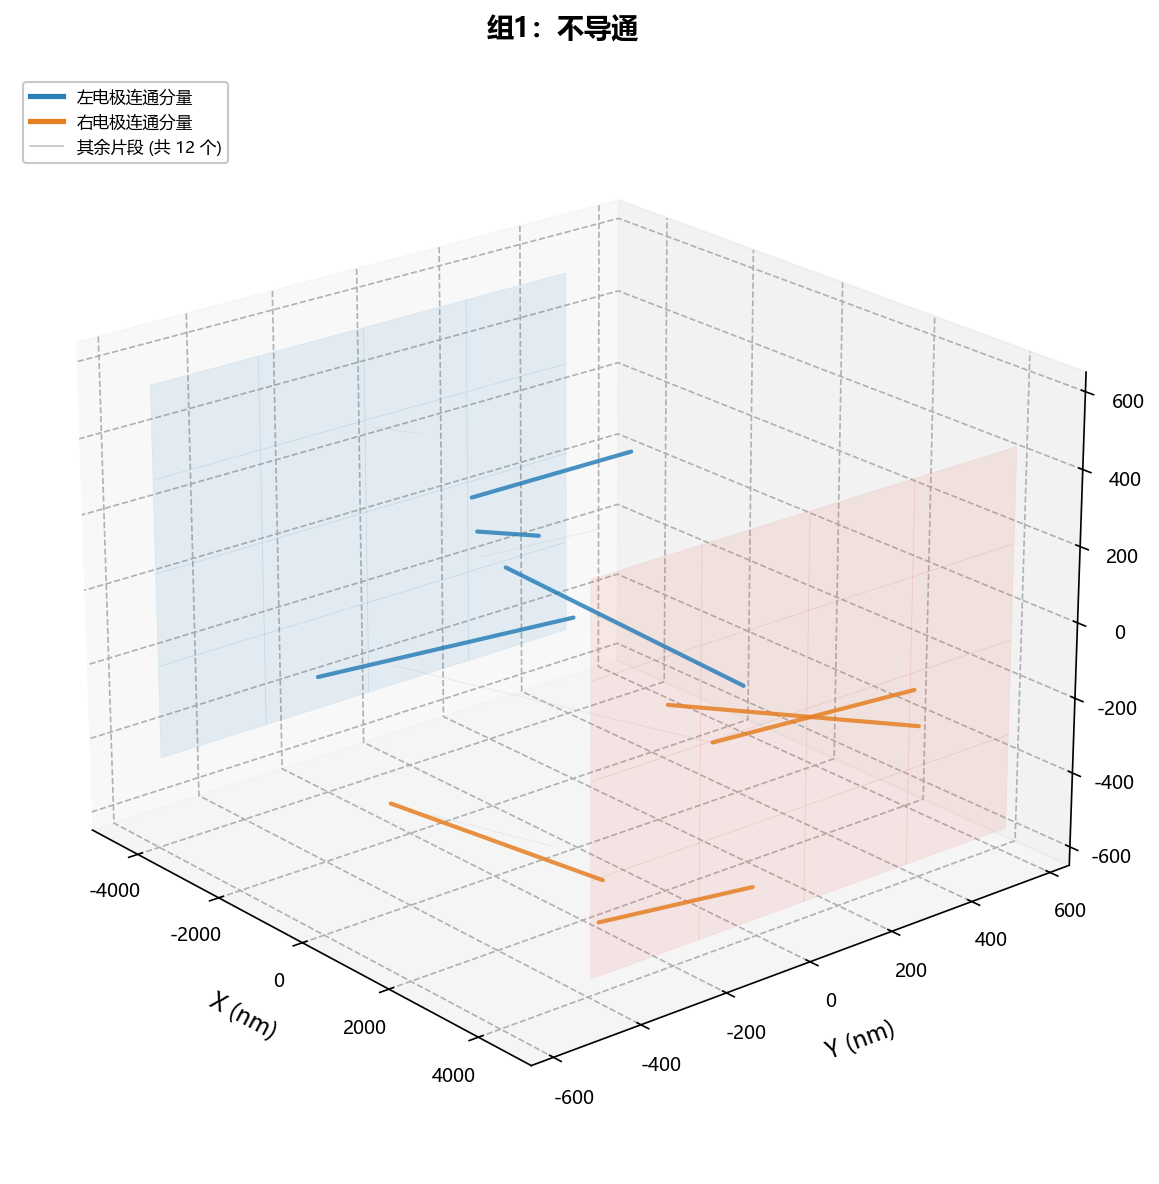

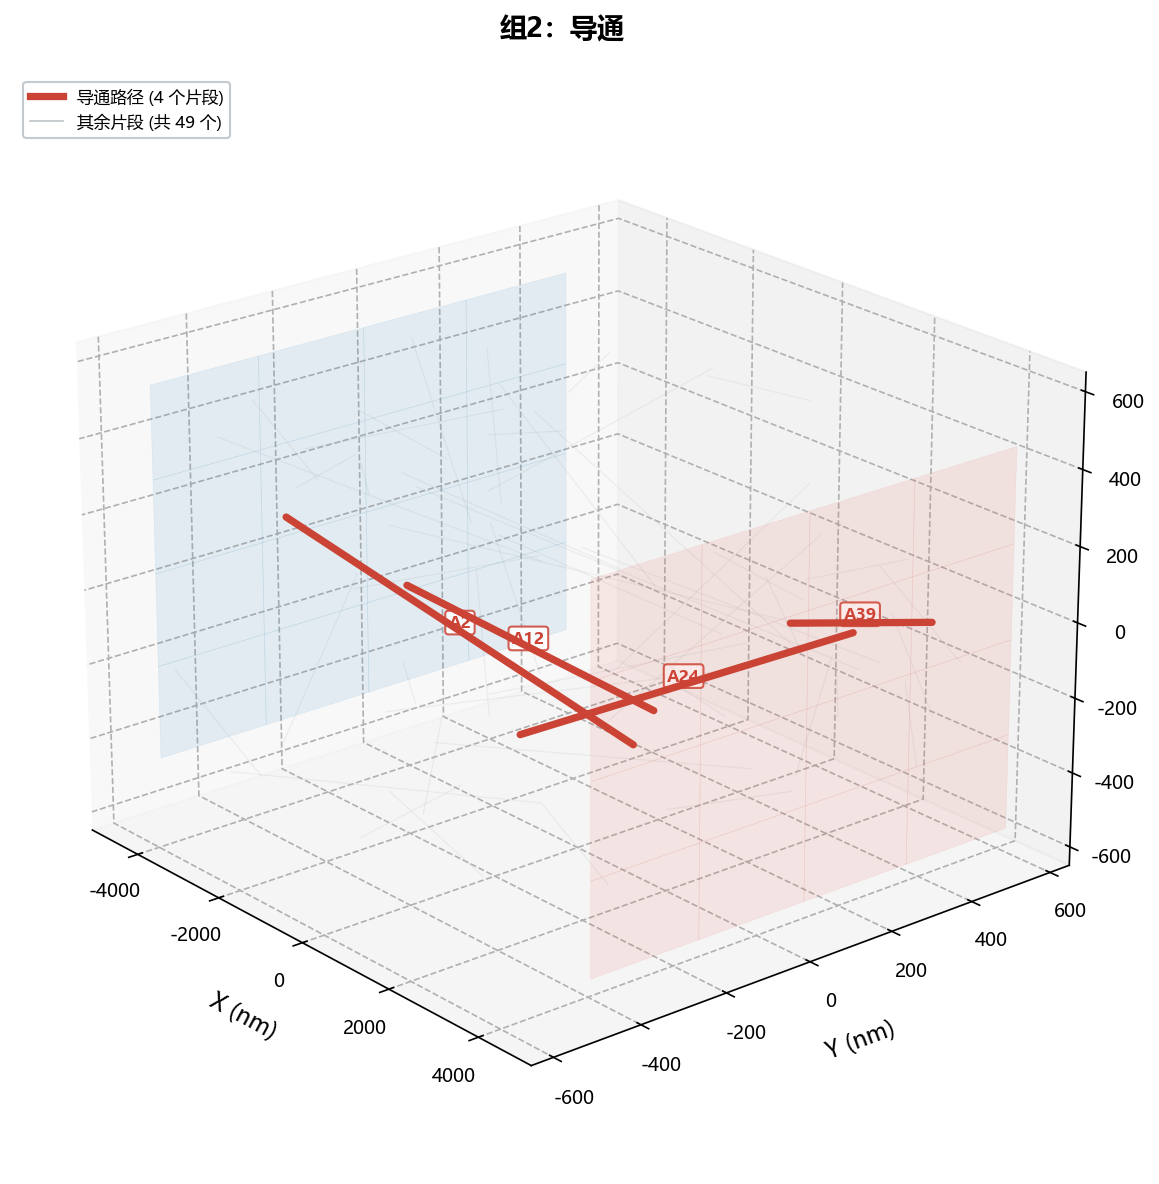

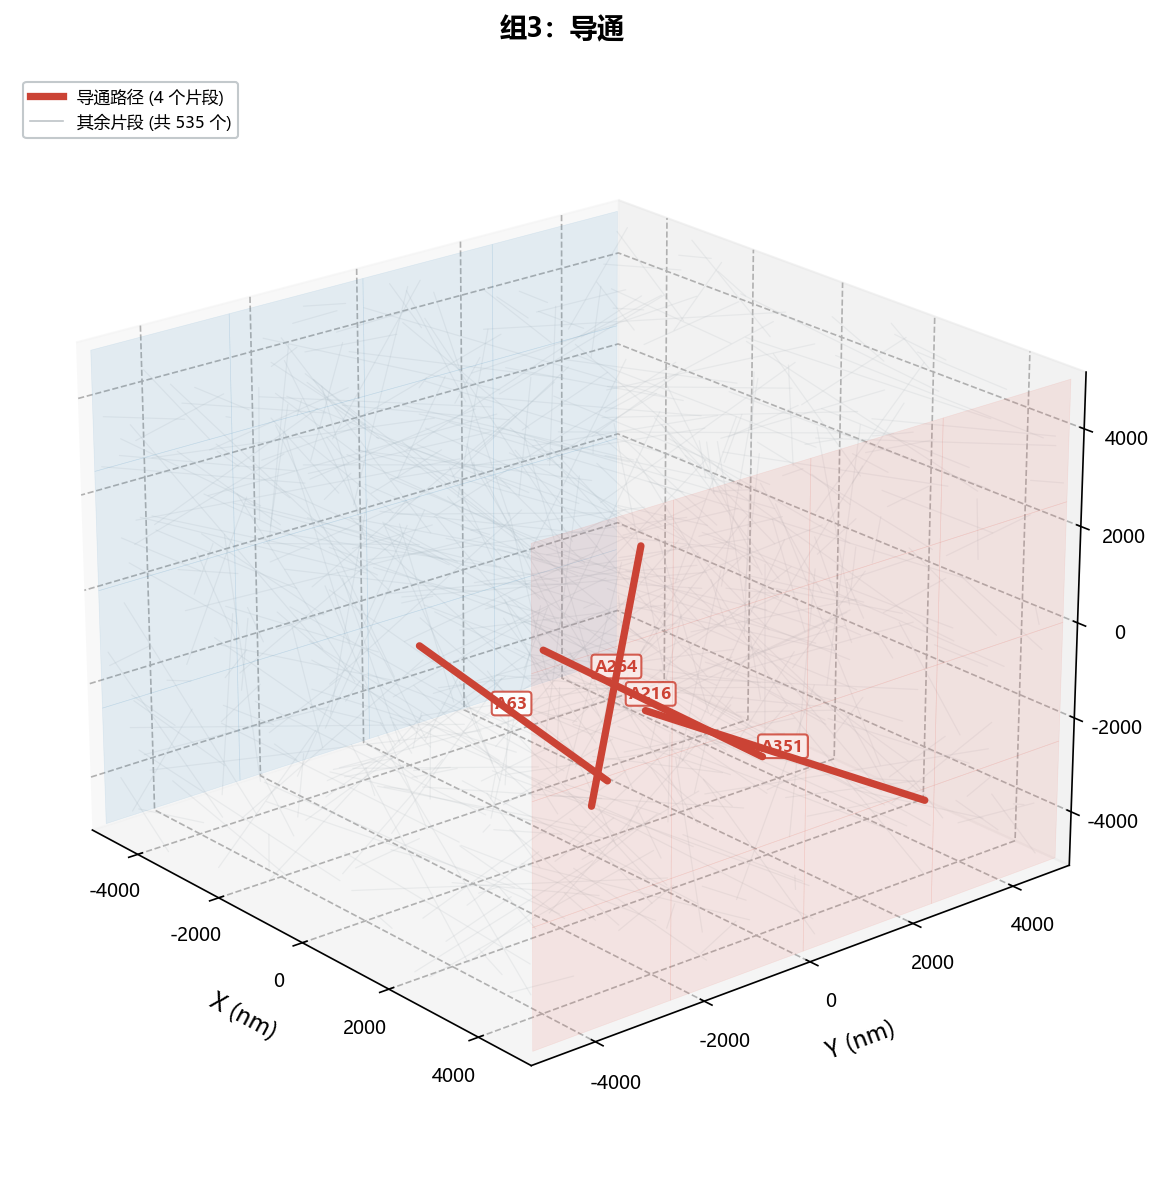

In [14]:
# ── 统一样式 ──
plt.rcParams.update({
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 11,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "grid.alpha": 0.3, "grid.linestyle": "--",
    "legend.frameon": True, "legend.framealpha": 0.9, "legend.edgecolor": "#bdc3c7",
})
C1 = {
    "path": "#cb4335", "left_comp": "#2980b9", "right_comp": "#e67e22",
    "other": "#bdc3c7", "face_left": "#2980b9", "face_right": "#e74c3c",
}


def reachable_nodes(adjacency: np.ndarray, starts: np.ndarray) -> set[int]:
    reached = set(map(int, np.flatnonzero(starts)))
    queue = deque(reached)
    while queue:
        node = queue.popleft()
        for neighbor in map(int, np.flatnonzero(adjacency[node])):
            if neighbor not in reached:
                reached.add(neighbor)
                queue.append(neighbor)
    return reached


def plot_sheet(sheet_name: str, result: dict):
    """绘制单个微构体的三维导通结构图（优化版）"""
    fig = plt.figure(figsize=(13, 8))
    ax = fig.add_subplot(111, projection="3d")
    ax.view_init(elev=22, azim=-40)

    path_indices = {pid - 1 for pid in (result["path"] or [])}
    left_comp = reachable_nodes(result["adjacency"], result["left"])
    right_comp = reachable_nodes(result["adjacency"], result["right"])

    # ── 逐片段绘制 ──
    for idx, seg in enumerate(result["segments"]):
        if idx in path_indices:
            color, lw, alpha, zorder = C1["path"], 3.5, 1.0, 10
        elif result["path"] is None and idx in left_comp:
            color, lw, alpha, zorder = C1["left_comp"], 2.0, 0.85, 5
        elif result["path"] is None and idx in right_comp:
            color, lw, alpha, zorder = C1["right_comp"], 2.0, 0.85, 5
        else:
            color, lw, alpha, zorder = C1["other"], 0.6, 0.22, 1

        ax.plot(
            [seg.p0[0], seg.p1[0]],
            [seg.p0[1], seg.p1[1]],
            [seg.p0[2], seg.p1[2]],
            color=color, lw=lw, alpha=alpha, zorder=zorder,
            solid_capstyle="round",
        )

    # ── 路径节点标注 ──
    for pid in (result["path"] or []):
        idx = pid - 1
        seg = result["segments"][idx]
        mid = 0.5 * (seg.p0 + seg.p1)
        ax.text(
            mid[0], mid[1], mid[2],
            f"A{pid}", fontsize=8, fontweight="bold",
            color=C1["path"], ha="center", va="bottom",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                       edgecolor=C1["path"], alpha=0.85),
        )

    # ── 带电面 ──
    half = result["half_extents"]
    yy, zz = np.meshgrid(
        np.linspace(-half[1], half[1], 5),
        np.linspace(-half[2], half[2], 5),
    )
    for x_val, fc, label in [
        (-half[0], C1["face_left"],  "左带电面 X=-5000"),
        ( half[0], C1["face_right"], "右带电面 X=+5000"),
    ]:
        ax.plot_surface(
            np.full_like(yy, x_val), yy, zz,
            color=fc, alpha=0.10, shade=False,
            edgecolor=fc, linewidth=0.3, zorder=0,
        )

    # ── 坐标轴 ──
    pad = max(30, 0.03 * np.max(half))
    ax.set_xlim(-half[0] - pad, half[0] + pad)
    ax.set_ylim(-half[1] - pad, half[1] + pad)
    ax.set_zlim(-half[2] - pad, half[2] + pad)
    ax.set_xlabel("X (nm)", labelpad=8)
    ax.set_ylabel("Y (nm)", labelpad=8)
    ax.set_zlabel("Z (nm)", labelpad=8)

    status = "导通" if result["conductive"] else "不导通"
    ax.set_title(f"{sheet_name}：{status}", fontsize=13, fontweight="bold", pad=18)

    # ── 手工图例 ──
    items = []
    if result["path"] is not None:
        items.append(Line2D([0],[0], color=C1["path"], lw=3.5,
                     label=f"导通路径 ({len(result['path'])} 个片段)"))
    if result["path"] is None:
        items.append(Line2D([0],[0], color=C1["left_comp"], lw=2.5,
                     label="左电极连通分量"))
        items.append(Line2D([0],[0], color=C1["right_comp"], lw=2.5,
                     label="右电极连通分量"))
    items.append(Line2D([0],[0], color=C1["other"], lw=0.8,
                 label=f"其余片段 (共 {len(result['segments'])} 个)"))
    ax.legend(handles=items, loc="upper left", fontsize=8, ncol=1)

    plt.tight_layout()
    return fig, ax


for sheet_name, result in results.items():
    fig, ax = plot_sheet(sheet_name, result)
    plt.show()

## 10. 第一问结论与模型边界

本次计算严格采用“一行一个独立实际片段”的口径：

- 不拼接同源行；
- 不恢复或补足到5000 nm；
- 不生成周期副本；
- 内部端点为真实圆盖，边界端点为真实边界切面；
- 只按主单元内直接欧氏距离连接；
- 左右两个X面作为不同电极。

节点数分别为12、49、535，补生成片段数均为0。最终判定为

\[
\boxed{\text{组1不导通，组2导通，组3导通}}.
\]

组2的一条路径为附件数据行 2→12→24→39，组3为 63→264→216→351；
组1不存在同时接触左右电极的普通连通分量。

最接近1.8 nm阈值的连接距离为1.7786710871 nm，不连接距离为1.8439571373 nm，
均与阈值保持明显间隔。